In [4]:
"""Exercise 2 for Group Meeting 19-11-2024

Evaliduate wether scGPT fine-tuned model is generalizing well to unseen data.

We will compare scGPT fine-tuned model with a no data leakage split w/ and without batch correction for datasets as well as a no data leakage split w/ and without batch correction for datasets.

We will also compare the performance of the model against a model trained w/ raw normalized batch corrected data.

Metrics to be considered are recall, precision and macro F1 score.


Structure of the script:
    1. Imports, Variables, Functions
    2. Load Data
    3. Train Models
    4. Evaliduate Models

"""

# 1. Imports, Variables, Functions
# imports
import numpy as np
import pandas as pd
import scanpy as sc
import pickle, os, sys
import anndata as ad
from typing import *
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
import logging
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(message)s")
# variables
model_paths = [
    ("mixed", "../outputs/run-24-11-14-23"),
    ("stratified", "../outputs/run-24-11-14-24"),
    ("stratified batch corrected", "../outputs/run-24-11-15-06"),
]


# functions
def load_run_output(input_dir: str) -> tuple:
    """Load the output of a run
    Args:
        input_dir (str): path to the run output directory
    Returns:
        loaded_variables (tuple): tuple of loaded variables
    """

    variables_to_load = [
        # "split",
        "predictions_test",
        "labels_test",
        "results_test",
        "all_outputs_test",
        "predictions_valid",
        "labels_valid",
        "results_valid",
        "all_outputs_valid",
        "predictions_train",
        "labels_train",
        "results_train",
        "all_outputs_train",
        "adata_orig",
        "id2type",
        "train_indices",
        "valid_indices",
    ]

    # initialize loaded variables as an empty tuple
    loaded_variables = ()

    # loop through variables
    for variable in variables_to_load:
        if variable.startswith("adata"):

            # do not load everything
            loaded_variable = ad.read_h5ad(
                os.path.join(input_dir, f"{variable}.h5ad")
                # , backed="r"
            )

        else:
            with open(os.path.join(input_dir, f"{variable}.pkl"), "rb") as f:
                loaded_variable = pickle.load(f)

        # add the loaded variable to the tuple
        loaded_variables += (loaded_variable,)

    print(f"Nº of loaded variables {len(loaded_variables)}")

    return loaded_variables


def merge_embeddings(output: List[Dict]) -> np.array:
    """Merge Embeddings
    Args:
        output (List[Dict]): List of dictionaries with embeddings
    Returns:
        np.array: Merged embeddings
    """
    for i in range(len(output)):
        embeddings_i = output[i]["cell_emb"].numpy()

        if i == 0:
            embeddings = embeddings_i
        else:
            embeddings = np.concatenate((embeddings, embeddings_i), axis=0)
    return embeddings


# 2. Load Data
data = dict()
for model_name, model_path in model_paths:
    data[model_name] = dict()
    (
        # split,
        predictions_test,
        labels_test,
        results_test,
        all_outputs_test,
        predictions_valid,
        labels_valid,
        results_valid,
        all_outputs_valid,
        predictions_train,
        labels_train,
        results_train,
        all_outputs_train,
        adata_orig,
        id2type,
        train_indices,
        valid_indices,
    ) = load_run_output(model_path)

    # merge embeddings
    for i in range(0, len(all_outputs_test)):
        print(f"Fold {i}")
        scgpt_emb_test = merge_embeddings(all_outputs_test[i])
        logging.info(f"SCGPT Embeddings Test Shape: {scgpt_emb_test.shape}")

        scgpt_emb_valid = merge_embeddings(all_outputs_valid[i])
        logging.info(f"SCGPT Embeddings Valid Shape: {scgpt_emb_valid.shape}")

        scgpt_emb_train = merge_embeddings(all_outputs_train[i])
        logging.info(f"SCGPT Embeddings Train Shape: {scgpt_emb_train.shape}")

    # store loaded data
    data[model_name]["predictions_test"] = predictions_test
    data[model_name]["labels_test"] = labels_test
    data[model_name]["results_test"] = results_test
    data[model_name]["all_outputs_test"] = all_outputs_test
    data[model_name]["scgpt_emb_test"] = scgpt_emb_test

    data[model_name]["predictions_valid"] = predictions_valid
    data[model_name]["labels_valid"] = labels_valid
    data[model_name]["results_valid"] = results_valid
    data[model_name]["all_outputs_valid"] = all_outputs_valid
    data[model_name]["scgpt_emb_valid"] = scgpt_emb_valid

    data[model_name]["predictions_train"] = predictions_train
    data[model_name]["labels_train"] = labels_train
    data[model_name]["results_train"] = results_train
    data[model_name]["all_outputs_train"] = all_outputs_train
    data[model_name]["scgpt_emb_train"] = scgpt_emb_train

    data[model_name]["adata_orig"] = adata_orig
    data[model_name]["id2type"] = id2type
    data[model_name]["valid_indices"] = valid_indices[0]
    data[model_name]["train_indices"] = train_indices[0]

Nº of loaded variables 16
Fold 0


2024-11-15 17:36:56,811 - SCGPT Embeddings Test Shape: (10782, 512)
2024-11-15 17:36:56,828 - SCGPT Embeddings Valid Shape: (2157, 512)
2024-11-15 17:36:59,222 - SCGPT Embeddings Train Shape: (19405, 512)


Nº of loaded variables 16
Fold 0


2024-11-15 17:37:09,345 - SCGPT Embeddings Test Shape: (11035, 512)
2024-11-15 17:37:09,356 - SCGPT Embeddings Valid Shape: (2131, 512)
2024-11-15 17:37:11,714 - SCGPT Embeddings Train Shape: (19178, 512)


Nº of loaded variables 16
Fold 0


2024-11-15 17:37:22,315 - SCGPT Embeddings Test Shape: (11035, 512)
2024-11-15 17:37:22,323 - SCGPT Embeddings Valid Shape: (2131, 512)
2024-11-15 17:37:25,070 - SCGPT Embeddings Train Shape: (19178, 512)


SyntaxError: keyword argument repeated: average (3517760161.py, line 223)

2024-11-15 18:23:33,556 - Model: mixed


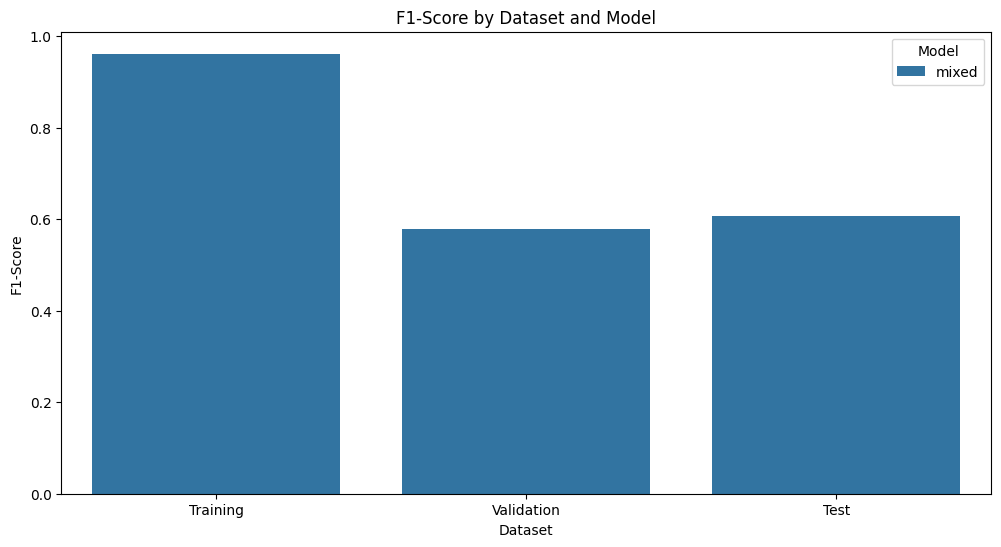

<Figure size 2000x1600 with 0 Axes>

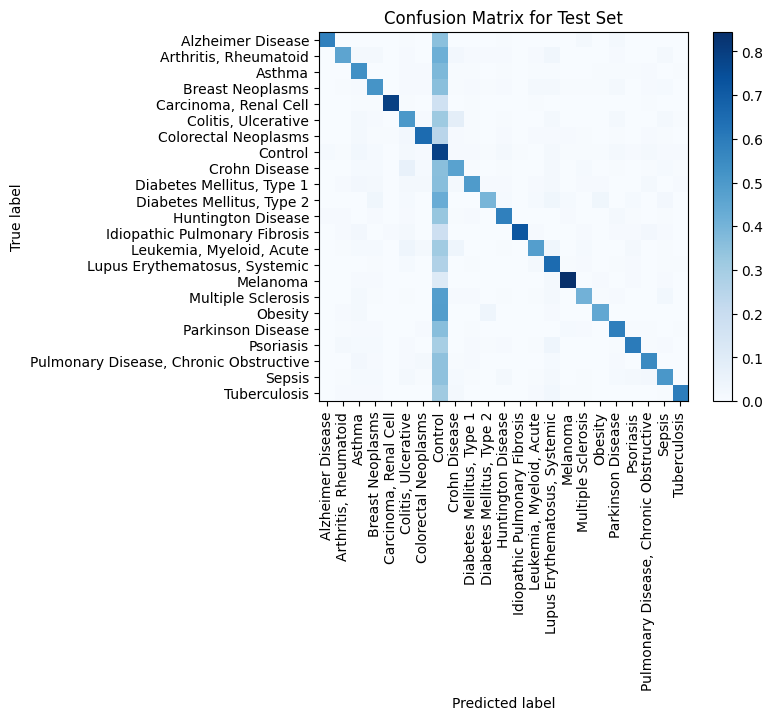

2024-11-15 18:24:00,624 - Model: stratified


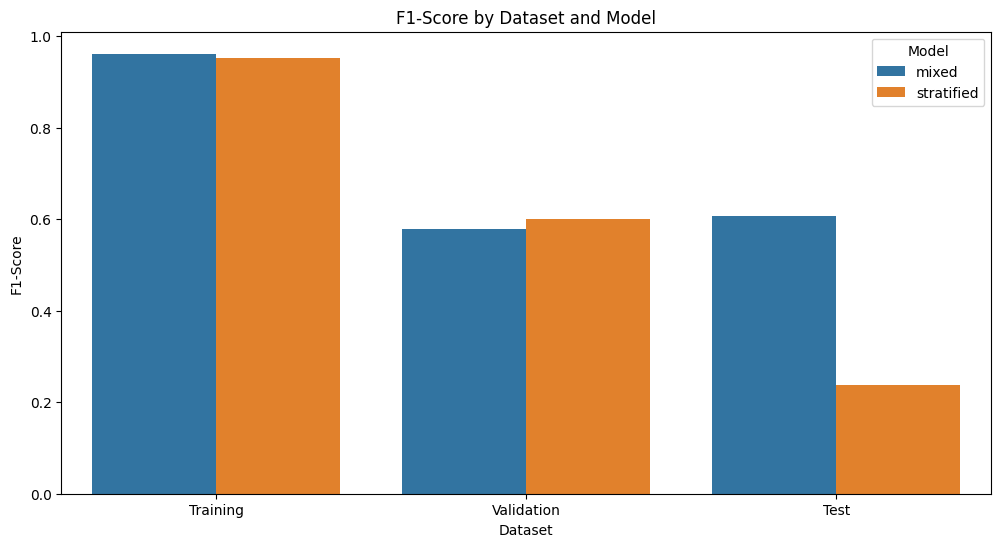

<Figure size 2000x1600 with 0 Axes>

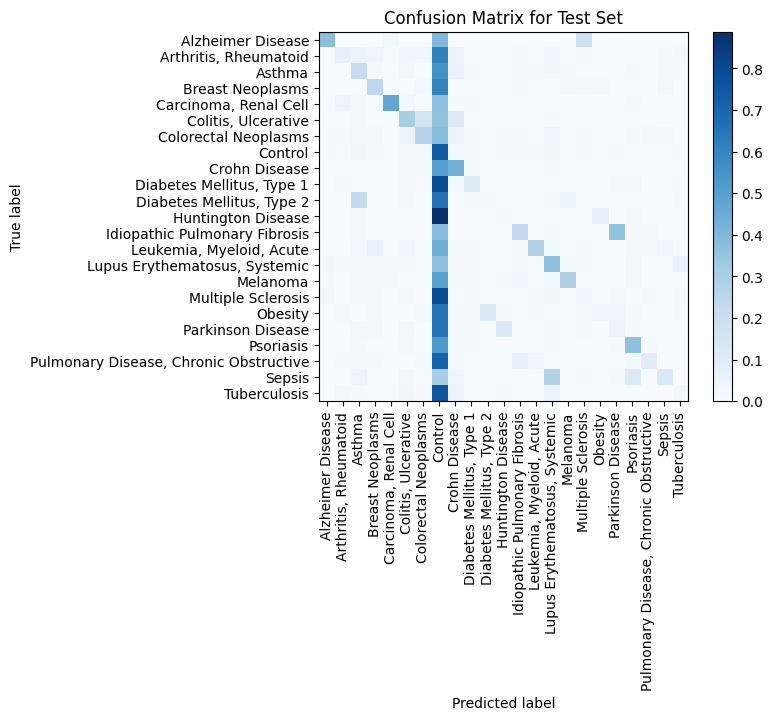

2024-11-15 18:24:44,089 - Model: stratified batch corrected


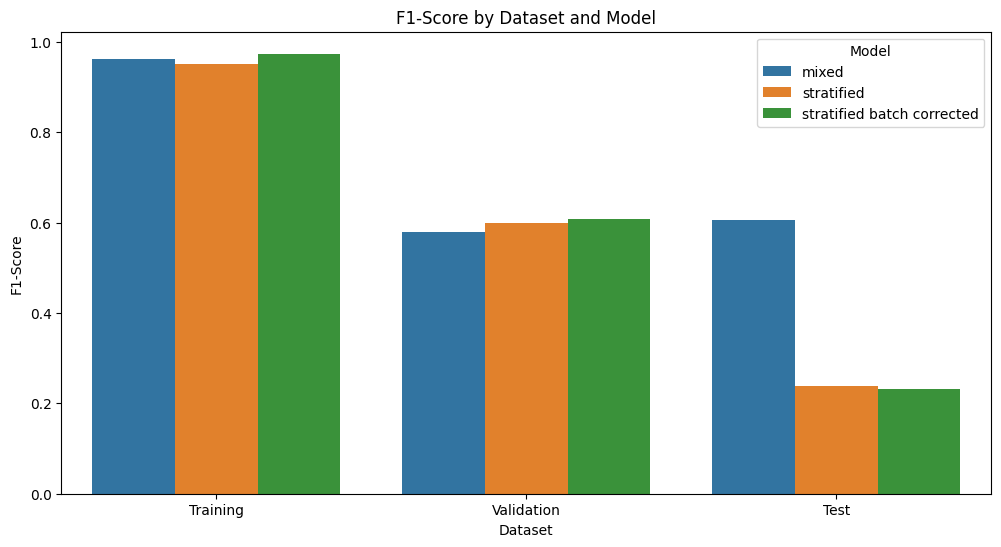

<Figure size 2000x1600 with 0 Axes>

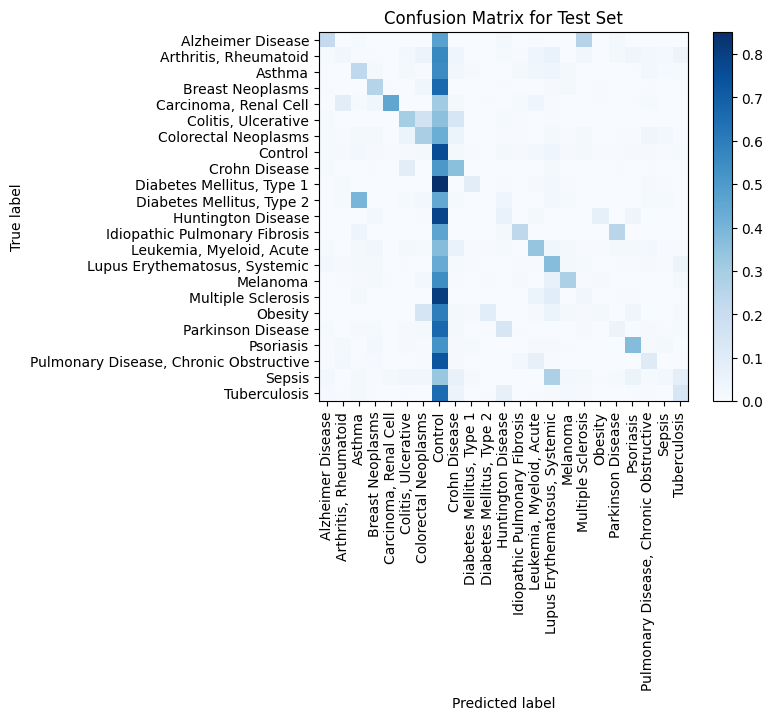

In [8]:
import seaborn as sns

results = []
# 3. Train Models
for model_name, model_data in data.items():
    logging.info(f"Model: {model_name}")

    # load data
    adata_orig = model_data["adata_orig"]
    adata_test = adata_orig[adata_orig.obs[f"test_split_{i+1}"] == 1]
    adata = adata_orig[adata_orig.obs[f"test_split_{i+1}"] == 0]

    train_indices = model_data["train_indices"]
    valid_indices = model_data["valid_indices"]

    train_adata = adata[train_indices, :]
    valid_adata = adata[valid_indices, :]

    # define train and test data
    X_train = model_data["scgpt_emb_train"]
    y_train = train_adata.obs["mesh_disease"].to_numpy()

    X_valid = model_data["scgpt_emb_valid"]
    y_valid = valid_adata.obs["mesh_disease"].to_numpy()

    X_test = model_data["scgpt_emb_test"]
    y_test = adata_test.obs["mesh_disease"].to_numpy()

    # Create and train the model
    mlp = MLPClassifier(
        hidden_layer_sizes=(384, 256, 128, 64),  # Four hidden layers with varying sizes
        activation="relu",  # Activation function for the hidden layers
        solver="adam",  # Optimizer
        max_iter=500,  # Maximum number of iterations
        random_state=42,  # For reproducibility
    )
    mlp.fit(X_train, y_train)

    # 4. Evaluate Models
    # Predict
    y_pred_valid = mlp.predict(X_valid)
    y_pred_test = mlp.predict(X_test)
    y_pred_train = mlp.predict(X_train)

    # Predictions
    y_pred_train = mlp.predict(model_data["scgpt_emb_train"])
    y_pred_valid = mlp.predict(model_data["scgpt_emb_valid"])
    y_pred_test = mlp.predict(model_data["scgpt_emb_test"])

    # Collect metrics
    results.append(
        {
            "Model": model_name,
            "Dataset": "Training",
            "Accuracy": accuracy_score(y_train, y_pred_train),
            "F1-Score": f1_score(y_train, y_pred_train, average="macro"),
            "Precision": precision_score(y_train, y_pred_train, average="macro"),
            "Recall": recall_score(y_train, y_pred_train, average="macro"),
        }
    )
    results.append(
        {
            "Model": model_name,
            "Dataset": "Validation",
            "Accuracy": accuracy_score(y_valid, y_pred_valid),
            "F1-Score": f1_score(y_valid, y_pred_valid, average="macro"),
            "Precision": precision_score(y_valid, y_pred_valid, average="macro"),
            "Recall": recall_score(y_valid, y_pred_valid, average="macro"),
        }
    )
    results.append(
        {
            "Model": model_name,
            "Dataset": "Test",
            "Accuracy": accuracy_score(y_test, y_pred_test),
            "F1-Score": f1_score(y_test, y_pred_test, average="macro"),
            "Precision": precision_score(y_test, y_pred_test, average="macro"),
            "Recall": recall_score(y_test, y_pred_test, average="macro"),
        }
    )

    # Generate a confusion matrix for the test set
    conf_matrix = confusion_matrix(y_test, y_pred_test)

    # Normalize the confusion matrix by row (true labels) to show proportions
    conf_matrix_normalized = (
        conf_matrix.astype("float") / conf_matrix.sum(axis=1)[:, np.newaxis]
    )

    # Display the normalized confusion matrix with proportional coloring
    disp_normalized = ConfusionMatrixDisplay(
        confusion_matrix=conf_matrix_normalized, display_labels=np.unique(y_test)
    )

    # Plot the confusion matrix

    plt.figure(figsize=(10, 8), dpi=200)

    disp_normalized.plot(
        cmap=plt.cm.Blues, include_values=False
    )  # Format values to show proportions

    plt.title("Confusion Matrix for Test Set")
    plt.xticks(rotation=90)
    plt.show()

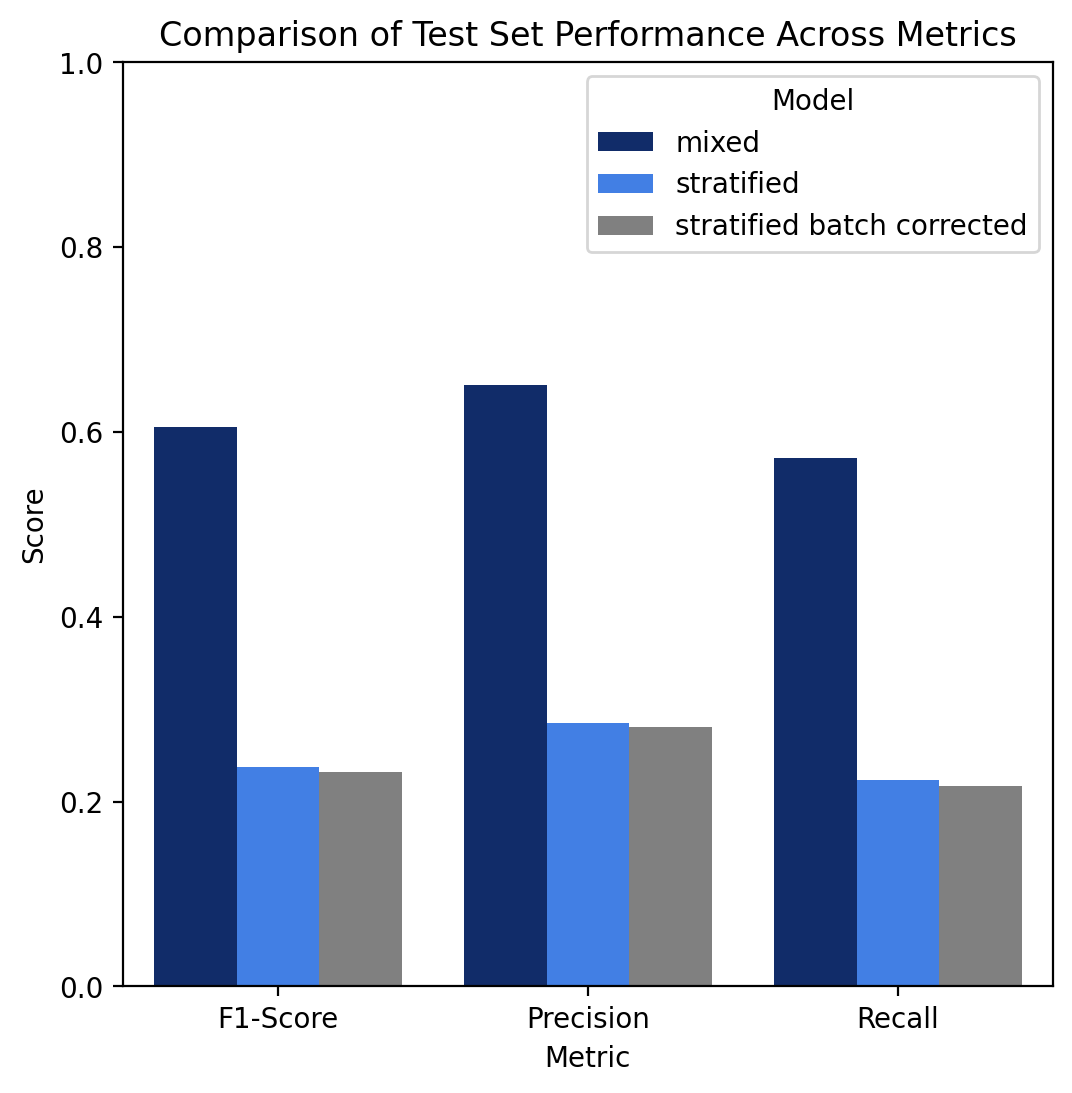

In [21]:
# Create a DataFrame from results
df_results = pd.DataFrame(results)

df_test_results = df_results[df_results["Dataset"] == "Test"]

# Melt the DataFrame to plot multiple metrics
df_test_results_melted = df_test_results.melt(
    id_vars=["Model", "Dataset"],
    value_vars=["F1-Score", "Precision", "Recall"],
    var_name="Metric",
    value_name="Score",
)


# Plot results for Test set across multiple metrics
plt.figure(figsize=(6, 6), dpi=200)
sns.barplot(
    data=df_test_results_melted,
    x="Metric",
    y="Score",
    hue="Model",
    palette=["#022778ff", "#2779ffff", "grey"],
)
plt.title("Comparison of Test Set Performance Across Metrics")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.legend(title="Model")
plt.ylim(0, 1)
plt.show()